<a href="https://colab.research.google.com/github/Ab-126/Deep_Learning/blob/main/Functional_Api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from keras.models import Model
from keras.layers import *

In [3]:
x = Input(shape=(3, ))

In [4]:
hidden1 = Dense(128, activation='relu')(x)
hidden2 = Dense(64, activation='relu')(hidden1)

output1 = Dense(1, activation='linear')(hidden2)
output2 = Dense(1, activation='sigmoid')(hidden2)

In [5]:
model = Model(inputs=x, outputs=[output1, output2])

In [6]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │        512 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,898 (34.76 KB)

 Trainable params: 8,898 (34.76 KB)

 Non-trainable params: 0 (0.00 B)

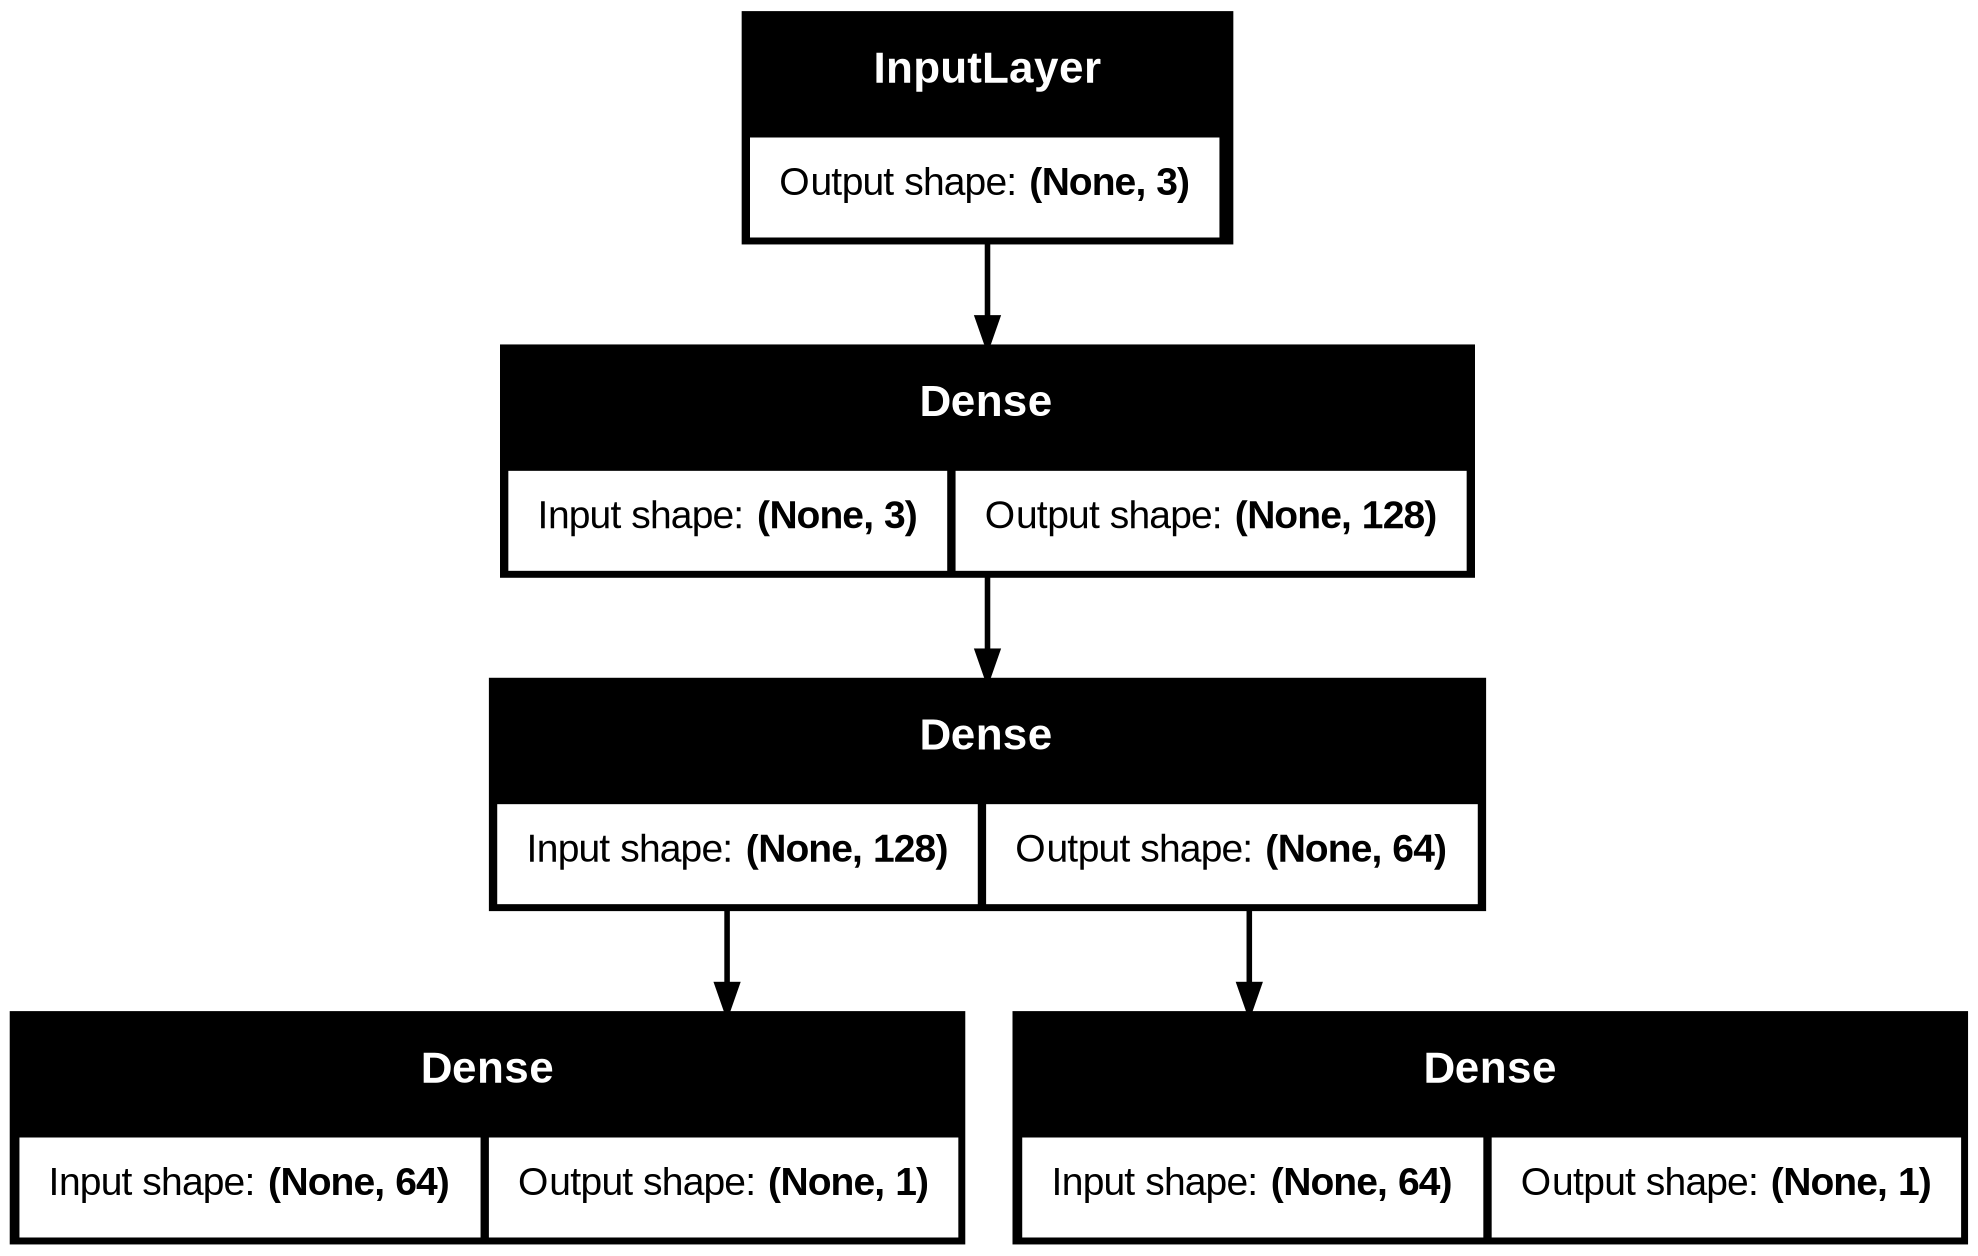

In [7]:
from keras.utils import plot_model
plot_model(model, show_shapes=True)

# Multiple Inputs

In [8]:
inputA = Input(shape=(32, ))
inputB = Input(shape=(128, ))

In [9]:
x = Dense(8, activation='relu')(inputA)
x1 = Dense(4, activation='relu')(x)

In [11]:
y = Dense(64, activation='relu')(inputB)
y1 = Dense(32, activation='relu')(y)
y2 = Dense(4, activation='relu')(y1)

In [12]:
combined = concatenate([x1, y1])

In [13]:
z = Dense(2, activation="relu")(combined)
z1 = Dense(1, activation="linear")(z)

In [14]:
model = Model(inputs=[inputA, inputB], outputs=z1)

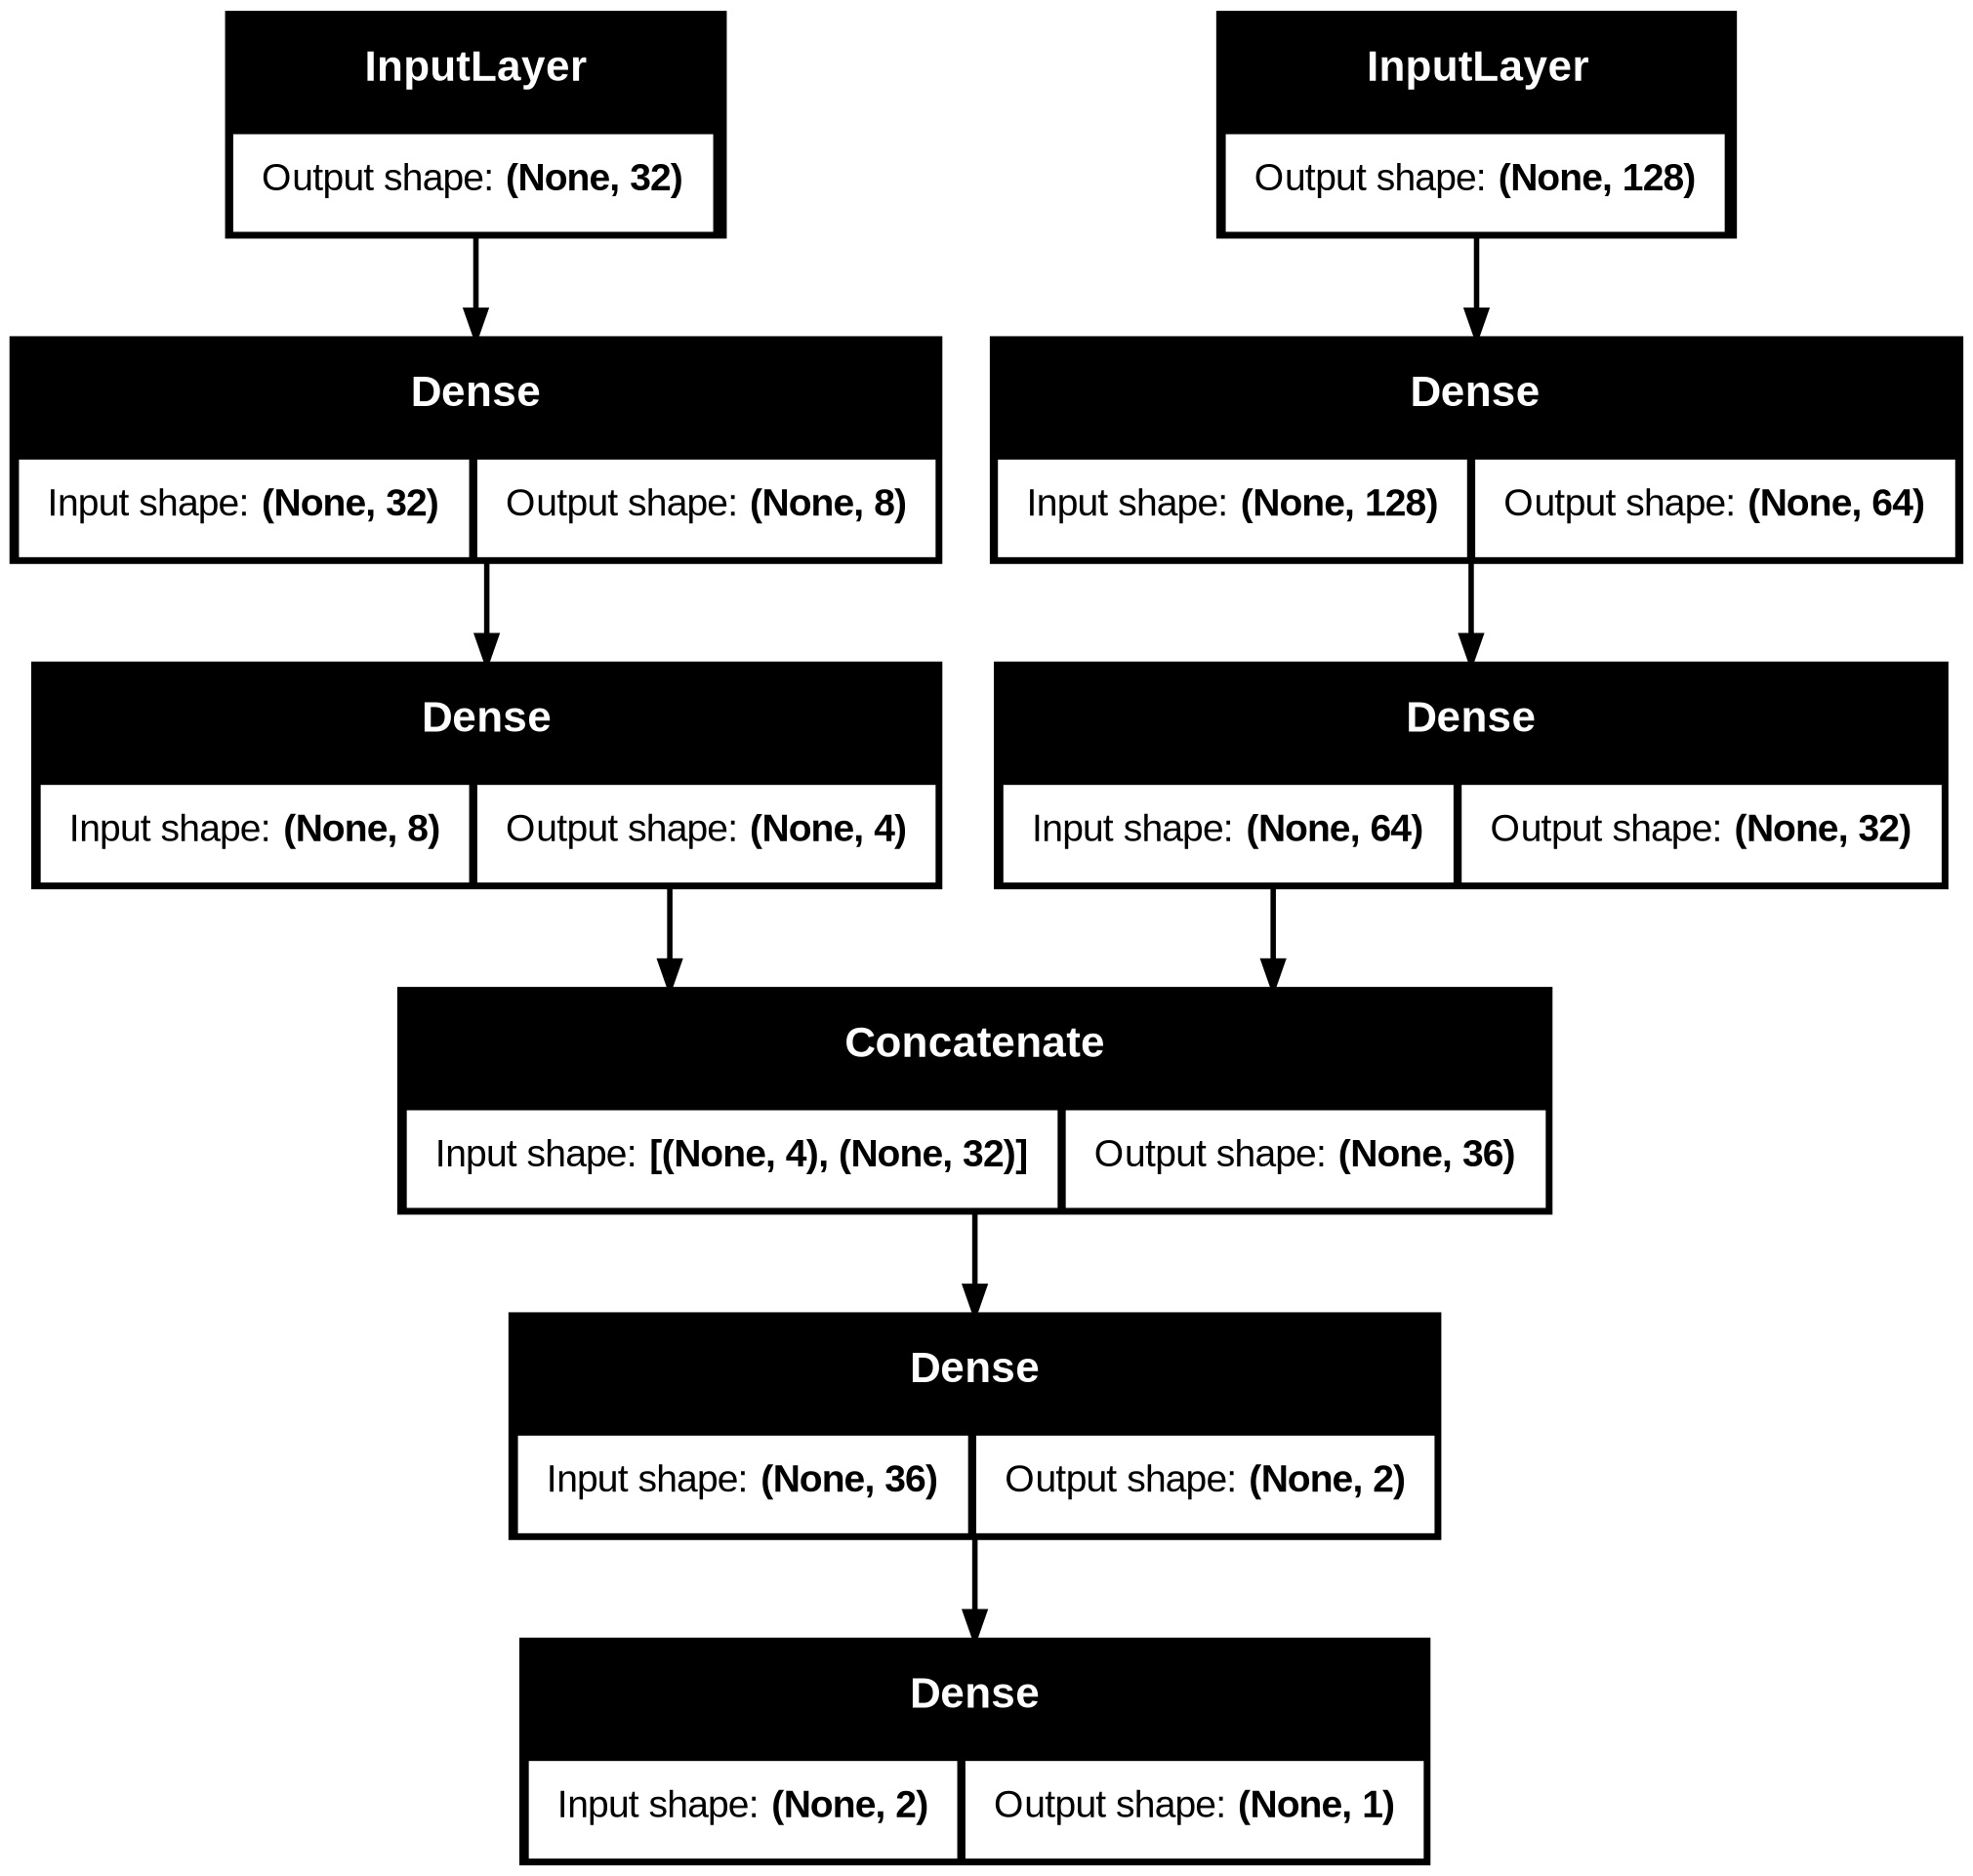

In [16]:
plot_model(model, show_shapes=True)

# Predicting age and gender, from images

In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aadyasingh55/face-age-gender-dataset")

print("Path to dataset files:", path)

100%|██████████| 522M/522M [00:13<00:00, 41.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aadyasingh55/face-age-gender-dataset/versions/1


In [18]:
import os

os.listdir(path)

['face_dataset']

In [19]:
train_path = os.path.join(path, 'face_dataset', 'train')
test_path = os.path.join(path, 'face_dataset', 'test')

In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd

In [26]:
train_csv_path = os.path.join(path, 'face_dataset', 'train.csv')
test_csv_path = os.path.join(path, 'face_dataset', 'test.csv')

In [27]:
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

In [29]:
test_df.head()

,id,full_path
0,0,test/00000.jpg
1,1,test/00001.jpg
2,2,test/00002.jpg
3,3,test/00003.jpg
4,4,test/00004.jpg


In [31]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=30,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

In [44]:
train_generator = train_datagen.flow_from_dataframe(train_df,
                                                    directory=train_path,
                                                    x_col='full_path',
                                                    y_col=['age','gender'],
                                                    target_size=(200,200),
                                                    class_mode='multi_output')

# test_generator = test_datagen.flow_from_dataframe(test_df,
#                                                     directory=test_path,
#                                                     x_col='full_path',
#                                                     y_col=['age','gender'],
#                                                     target_size=(200,200),
#                                                   class_mode='multi_output')

Found 0 validated image filenames.


In [36]:
from keras.applications.resnet50 import ResNet50
from keras.layers import *
from keras.models import Model

In [37]:
resnet = ResNet50(include_top=False, input_shape=(200,200,3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [38]:
resnet = ResNet50(include_top=False, input_shape=(200,200,3))

resnet.trainable=False

output = resnet.layers[-1].output

flatten = Flatten()(output)

dense1 = Dense(512, activation='relu')(flatten)
dense2 = Dense(512,activation='relu')(flatten)

dense3 = Dense(512,activation='relu')(dense1)
dense4 = Dense(512,activation='relu')(dense2)

output1 = Dense(1,activation='linear',name='age')(dense3)
output2 = Dense(1,activation='sigmoid',name='gender')(dense4)

In [39]:
model = Model(inputs=resnet.input,outputs=[output1,output2])

In [40]:
model.compile(optimizer='adam', loss={'age': 'mae', 'gender': 'binary_crossentropy'}, metrics={'age': 'mae', 'gender': 'accuracy'},loss_weights={'age':1,'gender':99})

In [42]:
model.fit(train_generator, batch_size=32, epochs=5)

ValueError: The PyDataset has length 0